<a href="https://colab.research.google.com/github/Vinothr007/Skillentrix_Intern/blob/main/Capstone_Project_01_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***STEP 1: IMPORT LIBRARIES***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


***STEP 2: LOAD DATASET***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Telco-Customer-Churn.csv", encoding="latin1")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


***STEP 3: UNDERSTAND THE DATASET***

In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

# Dataset information
print("\nDataset Info:\n")
df.info()

Dataset Shape: (7043, 21)

Columns:

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null

***STEP 4: CHECK MISSING VALUES***

In [ ]:
# Check missing values

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


***STEP 5: DATA CLEANING***

In [ ]:
# TotalCharges column contains spaces
# Convert it to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values again
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Remove null values

df.dropna(inplace=True)

# Verify again
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


***STEP 6: REMOVE UNNECESSARY COLUMN***

In [ ]:
# customerID is not useful for prediction

df.drop('customerID', axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


***STEP 7: EXPLORATORY DATA ANALYSIS (EDA)***

**7.1 Target Variable Distribution**

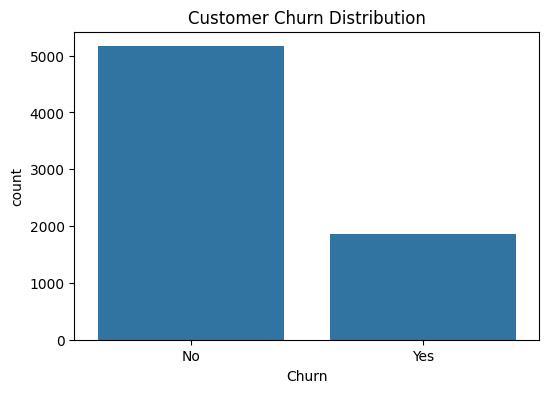

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

**7.2 Gender Distribution**

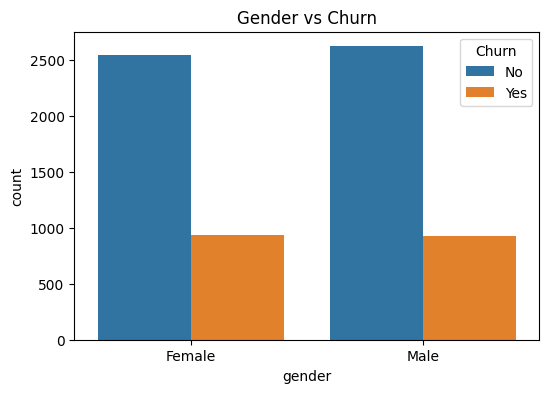

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Churn")
plt.show()

**7.3 Contract Type vs Churn**

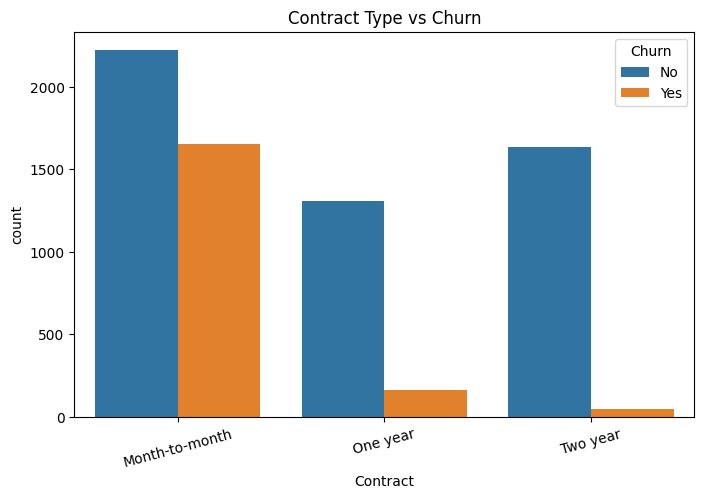

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

**7.4 Monthly Charges Distribution**

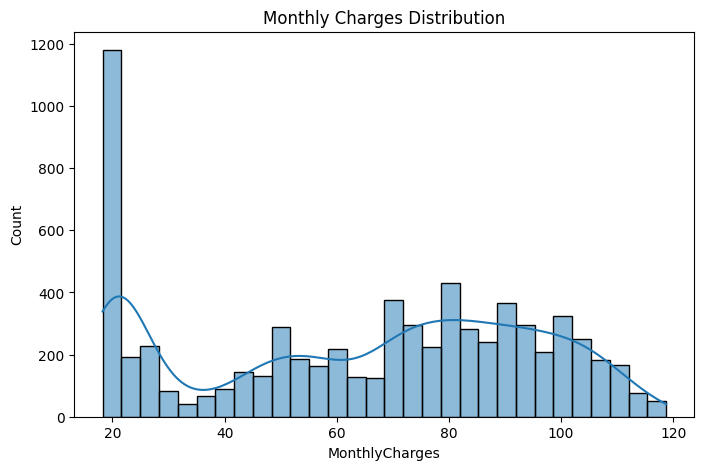

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Monthly Charges Distribution")
plt.show()

**7.5 Correlation Heatmap**

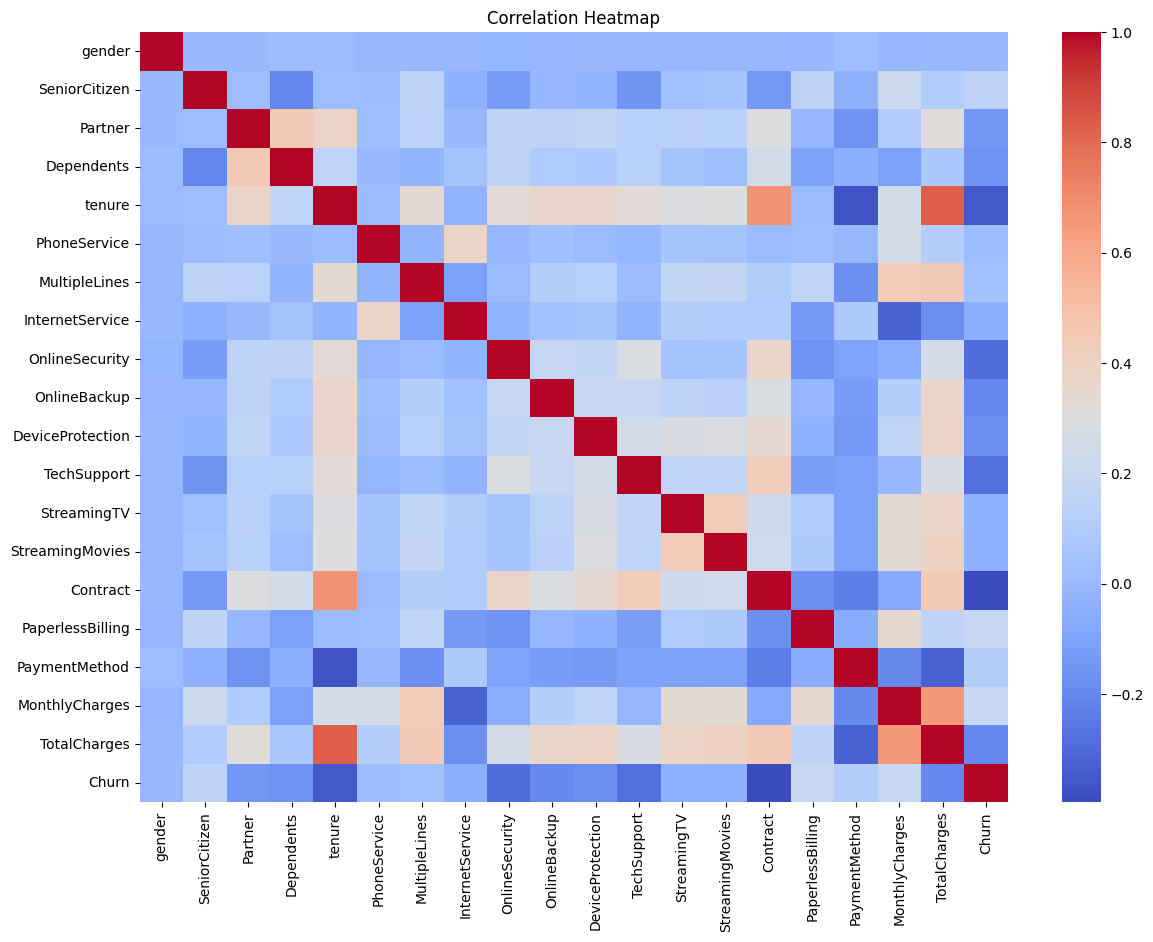

In [ ]:
# Convert target variable first

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Encode categorical columns temporarily for correlation

temp_df = df.copy()

le = LabelEncoder()

for col in temp_df.columns:
    if temp_df[col].dtype == 'object':
        temp_df[col] = le.fit_transform(temp_df[col])

plt.figure(figsize=(14,10))

sns.heatmap(temp_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

***STEP 8: FEATURE ENGINEERING***

In [ ]:
# Create new feature:
# Average monthly spending duration

df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,53.985714
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000


***STEP 9: ENCODE CATEGORICAL VARIABLES***

In [ ]:
# Encode categorical columns

categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,2,29.85,29.85,0,14.925000
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,3,56.95,1889.50,0,53.985714
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,1,36.050000
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,0,42.30,1840.75,0,40.016304
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,151.65,1,50.550000


***STEP 10: DEFINE FEATURES AND TARGET***

In [ ]:
# Features

X = df.drop('Churn', axis=1)

# Target

y = df['Churn']

print(X.shape)
print(y.shape)

(7032, 20)
(7032,)


***STEP 11: TRAIN TEST SPLIT***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (5625, 20)
Testing Data Shape: (1407, 20)


***STEP 12: FEATURE SCALING***

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

***STEP 13: LOGISTIC REGRESSION MODEL***

In [ ]:
# Create model

lr_model = LogisticRegression()

# Train model

lr_model.fit(X_train_scaled, y_train)

# Predictions

lr_pred = lr_model.predict(X_test_scaled)

# Probabilities

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

***STEP 14: EVALUATE LOGISTIC REGRESSION***

In [ ]:
print("LOGISTIC REGRESSION RESULTS")
print("="*40)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC AUC Score:", roc_auc_score(y_test, lr_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.7896233120113717
Precision: 0.6196319018404908
Recall: 0.5401069518716578
F1 Score: 0.5771428571428572
ROC AUC Score: 0.8371999420202825

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



***STEP 15: CONFUSION MATRIX***

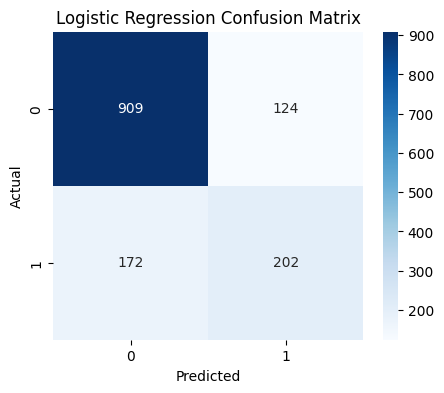

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

***STEP 16: RANDOM FOREST MODEL***

In [ ]:
# Create model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

# Predictions

rf_pred = rf_model.predict(X_test)

# Probabilities

rf_prob = rf_model.predict_proba(X_test)[:,1]

***STEP 17: EVALUATE RANDOM FOREST***

In [ ]:
print("RANDOM FOREST RESULTS")
print("="*40)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC Score:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

RANDOM FOREST RESULTS
Accuracy: 0.7903340440653873
Precision: 0.632996632996633
Recall: 0.5026737967914439
F1 Score: 0.5603576751117735
ROC AUC Score: 0.828941714853679

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



***STEP 18: XGBOOST MODEL***

In [ ]:
# Create model

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Train model

xgb_model.fit(X_train, y_train)

# Predictions

xgb_pred = xgb_model.predict(X_test)

# Probabilities

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

***STEP 19: EVALUATE XGBOOST***

In [ ]:
print("XGBOOST RESULTS")
print("="*40)

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC AUC Score:", roc_auc_score(y_test, xgb_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

XGBOOST RESULTS
Accuracy: 0.7896233120113717
Precision: 0.6181818181818182
Recall: 0.5454545454545454
F1 Score: 0.5795454545454546
ROC AUC Score: 0.8318018750226482

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



***STEP 20: ROC CURVE COMPARISON***

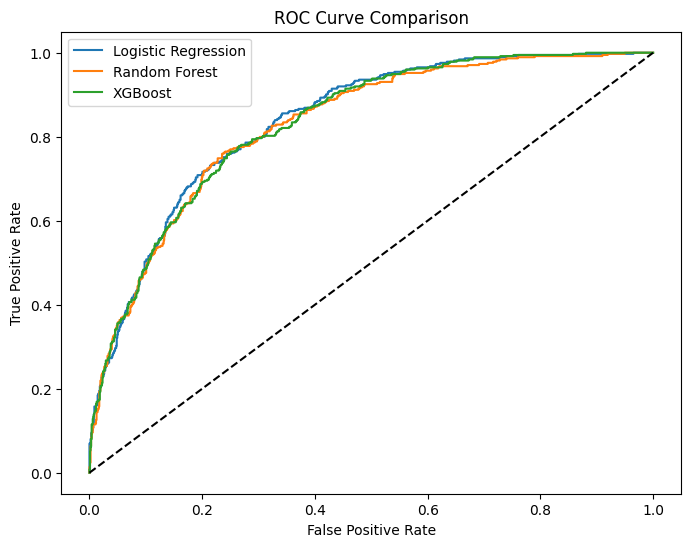

In [ ]:
# Logistic Regression ROC

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

# Random Forest ROC

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# XGBoost ROC

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# Plot

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression')
plt.plot(rf_fpr, rf_tpr, label='Random Forest')
plt.plot(xgb_fpr, xgb_tpr, label='XGBoost')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

***STEP 21: MODEL COMPARISON***

In [ ]:
results = pd.DataFrame({

    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    'ROC_AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,ROC_AUC
0,Logistic Regression,0.789623,0.619632,0.540107,0.837200
1,Random Forest,0.790334,0.632997,0.502674,0.828942
2,XGBoost,0.789623,0.618182,0.545455,0.831802


***STEP 22: BEST MODEL SELECTION***

In [ ]:
best_model = results.sort_values(by='ROC_AUC', ascending=False)

best_model

,Model,Accuracy,Precision,Recall,ROC_AUC
0,Logistic Regression,0.789623,0.619632,0.540107,0.837200
2,XGBoost,0.789623,0.618182,0.545455,0.831802
1,Random Forest,0.790334,0.632997,0.502674,0.828942


***STEP 23: FEATURE IMPORTANCE (BUSINESS IMPACT)***

In [ ]:
# Feature Importance using Random Forest

importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf_model.feature_importances_

})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
4,tenure,0.137481
18,TotalCharges,0.136863
14,Contract,0.128569
17,MonthlyCharges,0.116223
19,AvgMonthlySpend,0.111861
11,TechSupport,0.060287
8,OnlineSecurity,0.059991
7,InternetService,0.043166
16,PaymentMethod,0.037444
9,OnlineBackup,0.030751


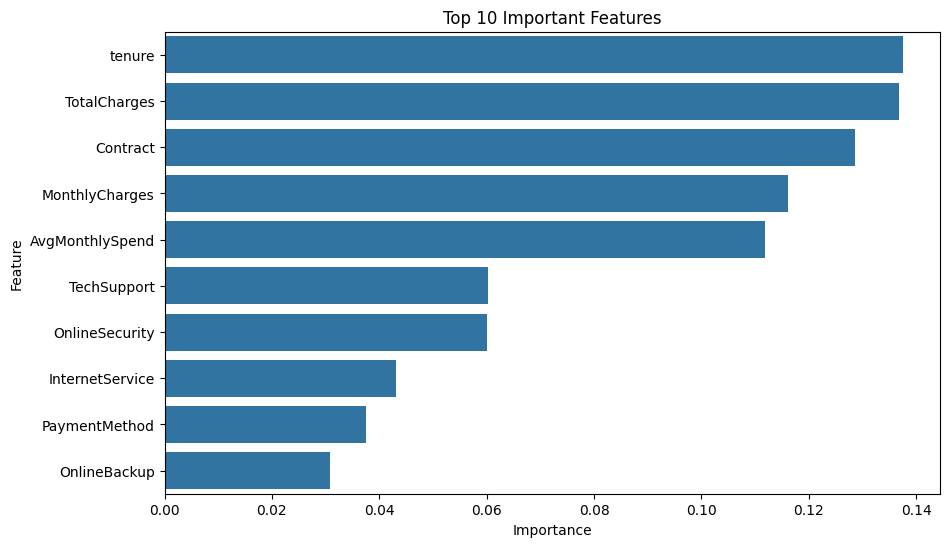

In [ ]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

***STEP 24: SHAP EXPLAINABILITY***

In [ ]:
# Install SHAP

!pip install shap

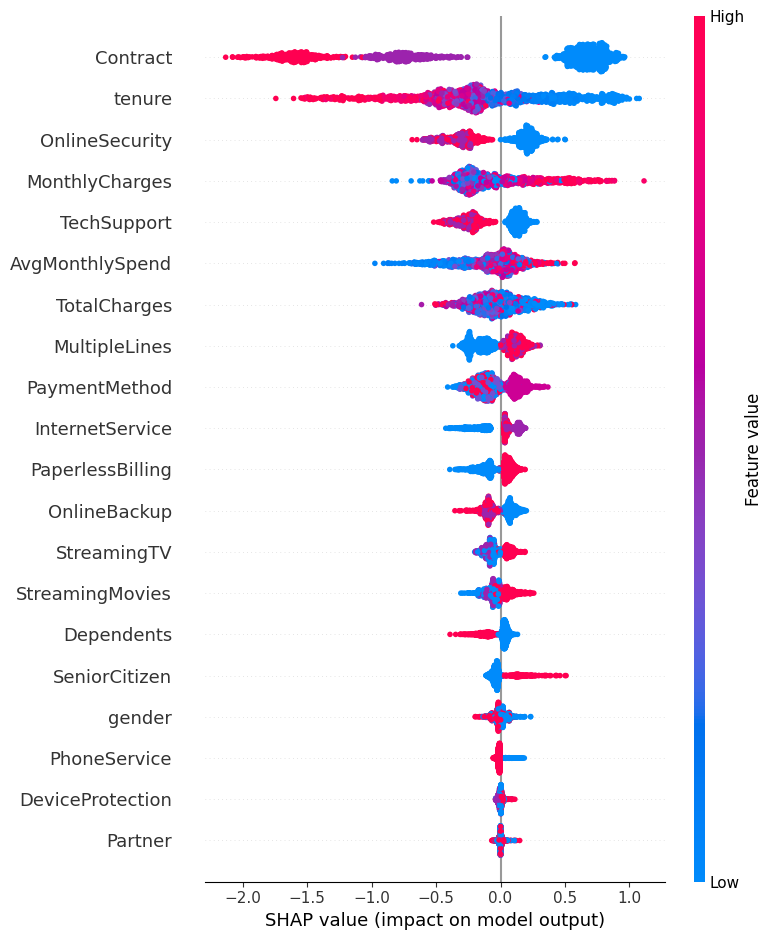

In [ ]:
import shap

# Create explainer

explainer = shap.TreeExplainer(xgb_model)

# SHAP values

shap_values = explainer.shap_values(X_test)

# Summary Plot

shap.summary_plot(shap_values, X_test)

***STEP 25: BUSINESS INSIGHTS***


BUSINESS INSIGHTS
===============================

1. Customers with month-to-month contracts are more likely to churn.

2. Customers with higher monthly charges show higher churn probability.

3. Customers with short tenure are at higher risk.

4. Long-term contract customers are more stable.

5. Electronic check payment users show higher churn rates.

6. Companies can reduce churn by:
   - Providing long-term offers
   - Giving loyalty discounts
   - Improving customer support
   - Offering personalized retention plans


***STEP 26: FINAL CONCLUSION***

FINAL CONCLUSION
==================================

This project successfully predicts customer churn using
Machine Learning models.

Models Used:
1. Logistic Regression
2. Random Forest
3. XGBoost

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- ROC-AUC

XGBoost generally performs best because it handles
complex patterns effectively.

SHAP Explainability helped identify the important
features influencing customer churn.

This project can help telecom companies improve
customer retention and reduce revenue loss.